## Radiative Heating and Precipitation Relation

### Import package

In [16]:
import os
import sys

import numpy as np
import netCDF4 as nc

from pathlib import Path
from datetime import datetime
from scipy.signal import detrend

from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm

sys.path.append("/home/b11209013/Manuscript_Prep/KW_CRI/src")
import spectrum

### Helper functions

In [17]:
def convert_time(time_variable: nc.Variable) -> np.ndarray:
    """Return a netCDF time coordinate as YYYY-MM-DD strings."""
    dates = nc.num2date(
        time_variable[:],
        units=time_variable.units,
        calendar=getattr(time_variable, "calendar", "standard"),
    )
    return np.asarray([date.strftime("%Y-%m-%d") for date in dates])


def as_float_array(values: np.ndarray) -> np.ndarray:
    """Convert a netCDF array to float and replace masked values by NaN."""
    masked_values = np.ma.asarray(values, dtype=np.float64)
    return np.asarray(masked_values.filled(np.nan))


### Configuration and data loading

In [18]:
DATA_PATH = Path("/data92/b11209013")
START_DATE = datetime(2006, 1, 1).strftime("%Y-%m-%d")
END_DATE = datetime(2018, 1, 1).strftime("%Y-%m-%d")
LATITUDE_BOUNDS = (-5.0, 5.0)

# Longwave radiative heating
with nc.Dataset(DATA_PATH / "CERES" / "column_LW_rm3harm.nc") as dataset:
    radiative_dates = convert_time(dataset.variables["time"])
    radiative_latitude = as_float_array(dataset.variables["lat"][:])
    radiative_longitude = as_float_array(dataset.variables["lon"][:])
    radiative_latitude_mask = (
        (radiative_latitude >= LATITUDE_BOUNDS[0])
        & (radiative_latitude <= LATITUDE_BOUNDS[1])
    )
    lw_heating = as_float_array(
        dataset.variables["column_LW"][:, radiative_latitude_mask, :]
    )

# Shortwave radiative heating
with nc.Dataset(DATA_PATH / "CERES" / "column_SW_rm3harm.nc") as dataset:
    shortwave_dates = convert_time(dataset.variables["time"])
    sw_heating = as_float_array(
        dataset.variables["column_SW"][:, radiative_latitude_mask, :]
    )

# Precipitation
with nc.Dataset(DATA_PATH / "ERA5_GRIB" / "Data" / "regrid" /"CWV.nc") as dataset:
    # all_dates = convert_time(dataset.variables["time"])
    # date_mask = (all_dates >= START_DATE) & (
        # all_dates < END_DATE
    # )
    # CWV_dates = all_dates[date_mask]

    CWV_latitude = as_float_array(dataset.variables["lat"][:])
    CWV_longitude = as_float_array(dataset.variables["lon"][:])
    CWV_latitude_mask = (
        (CWV_latitude >= LATITUDE_BOUNDS[0])
        & (CWV_latitude <= LATITUDE_BOUNDS[1])
    )
    CWV = as_float_array(
        dataset.variables["CWV"][
            :, CWV_latitude_mask, :
        ]
    )


### Preprocessing and segmentation

In [19]:
CHUNK_SIZE = 96
CHUNK_OVERLAP = CHUNK_SIZE // 2
hann_window = np.hanning(CHUNK_SIZE)

qr_heating = lw_heating + sw_heating

# calculate anomaly
qr_heating -= np.nanmean(qr_heating, axis=(0, -1), keepdims=True)
lw_heating -= np.nanmean(lw_heating, axis=(0, -1), keepdims=True)
sw_heating -= np.nanmean(sw_heating, axis=(0, -1), keepdims=True)

# symmetrizing the data
symmetric_fields = {
    "QR": spectrum.symm_asym(qr_heating, lat_axis=1)[0],
    "LW": spectrum.symm_asym(lw_heating, lat_axis=1)[0],
    "SW": spectrum.symm_asym(sw_heating, lat_axis=1)[0],
    "precipitation": spectrum.symm_asym(CWV, lat_axis=1)[0],
}

# chunking data
chunking_fields = {
    key: spectrum.chunking(
        symmetric_fields[key],
        time_axis=0,
        window_size=CHUNK_SIZE,
        overlap_size=CHUNK_OVERLAP
        )
    for key in symmetric_fields.keys()
}

n_segments, _, n_latitudes, n_longitudes = chunking_fields["QR"].shape
print(f"Windowed chunk shape: {chunking_fields['QR'].shape}")

Windowed chunk shape: (90, 96, 10, 360)


### Cross-spectral analysis

In [20]:
frequencies = np.fft.fftfreq(CHUNK_SIZE, d=1.0)
zonal_wavenumbers = np.fft.fftfreq(
    n_longitudes, d=1.0 / n_longitudes
)

source_chunks = {
    name: chunking_fields[name]
    for name in ("QR", "LW", "SW")
}

# Calculate one latitude-mean estimate for every time segment.
cross_spectrum, power_spectrum, precipitation_power_spectrum = (
    spectrum.calculate_segment_spectra(
        source_chunks=source_chunks,
        reference_chunks=chunking_fields["precipitation"],
        window_energy=float(np.mean(hann_window**2)),
    )
)

# Average across segments only; latitude was averaged in the function.
mean_cross_spectrum = {
    name: np.nanmean(values, axis=0)
    for name, values in cross_spectrum.items()
}
mean_power_spectrum = {
    name: np.nanmean(values, axis=0)
    for name, values in power_spectrum.items()
}
mean_precipitation_power_spectrum = np.nanmean(
    precipitation_power_spectrum, axis=0
)

# Form coherence from averaged spectra. Per-periodogram coherence is one.
coherence_squared = {
    name: spectrum.calculate_squared_coherence(
        mean_cross_spectrum=mean_cross_spectrum[name],
        mean_source_power=mean_power_spectrum[name],
        mean_reference_power=mean_precipitation_power_spectrum,
    )
    for name in source_chunks
}

cospectrum = {
    name: values.real for name, values in mean_cross_spectrum.items()
}
quadrature_spectrum = {
    name: values.imag for name, values in mean_cross_spectrum.items()
}
phase_degrees = {
    name: np.rad2deg(np.angle(values))
    for name, values in mean_cross_spectrum.items()
}


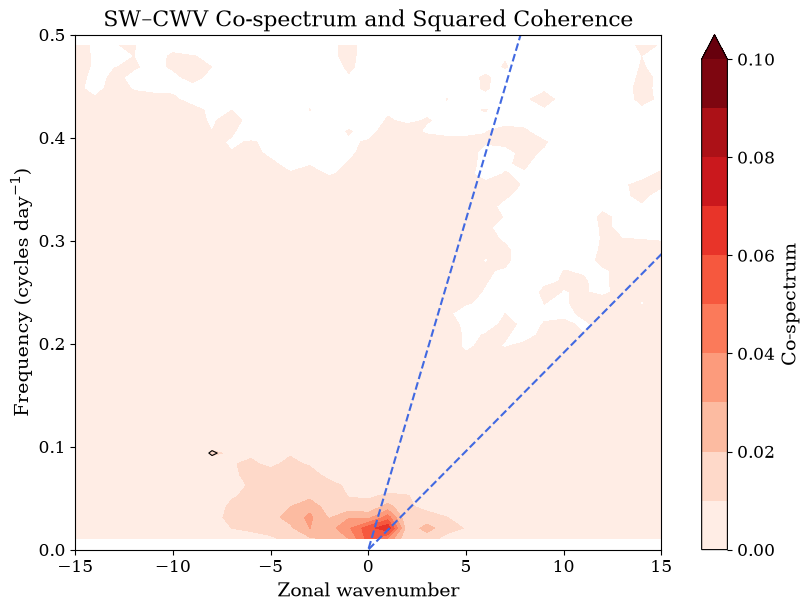

In [21]:
SOURCE_NAME = "SW"
COHERENCE_LEVELS = (0.5, 0.6, 0.8)

shifted_wavenumbers = np.fft.fftshift(zonal_wavenumbers)
shifted_frequencies = np.fft.fftshift(frequencies)
shifted_cospectrum = np.fft.fftshift(
    cospectrum[SOURCE_NAME], axes=(0, 1)
)
shifted_coherence = np.fft.fftshift(
    coherence_squared[SOURCE_NAME], axes=(0, 1)
)

# Retain positive temporal frequencies for the conventional display.
positive_frequency = shifted_frequencies > 0
frequency_display = shifted_frequencies[positive_frequency]
cospectrum_display = shifted_cospectrum[positive_frequency, :]
coherence_display = shifted_coherence[positive_frequency, :]

# Use a robust symmetric range so both covariance signs remain visible.
finite_cospectrum = np.abs(
    cospectrum_display[np.isfinite(cospectrum_display)]
)
if finite_cospectrum.size == 0:
    raise ValueError("The co-spectrum contains no finite values.")
color_limit = np.percentile(finite_cospectrum, 99)
color_limit = color_limit if color_limit > 0 else 1.0
shading_levels = np.linspace(0, 0.1, 11)


plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 18,
    }
)

figure, axis = plt.subplots(figsize=(8, 6), constrained_layout=True)

shading = axis.contourf(
    shifted_wavenumbers,
    frequency_display,
    cospectrum_display,
    levels=shading_levels,
    cmap="Reds",
    extend="max",
)

finite_coherence = coherence_display[np.isfinite(coherence_display)]
available_coherence_levels = []
if finite_coherence.size:
    available_coherence_levels = [
        level
        for level in COHERENCE_LEVELS
        if finite_coherence.min() < level < finite_coherence.max()
    ]
if available_coherence_levels:
    coherence_contours = axis.contour(
        shifted_wavenumbers,
        frequency_display,
        coherence_display,
        levels=available_coherence_levels,
        colors="black",
        linewidths=0.8,
    )
    axis.clabel(
        coherence_contours,
        fmt=lambda value: rf"$\gamma^2={value:.1f}$",
        fontsize=12,
        inline=True,
    )

axis.plot(
    shifted_wavenumbers,
    np.sqrt(9.81 * 8) * 86400.0 / (2*np.pi*6.371e6) * shifted_wavenumbers,
    color="royalblue", linestyle="--"
)

axis.plot(
    shifted_wavenumbers,
    np.sqrt(9.81 * 90) * 86400.0 / (2*np.pi*6.371e6) * shifted_wavenumbers,
    color="royalblue", linestyle="--"
)

axis.set(
    xlim=(-15, 15),
    ylim=(0, 0.5),
    xlabel="Zonal wavenumber",
    ylabel="Frequency (cycles day$^{-1}$)",
    title=f"{SOURCE_NAME}–CWV Co-spectrum and Squared Coherence",
)
cbar = figure.colorbar(shading, ax=axis, label="Co-spectrum")
cbar.set_ticks([0, 0.02, 0.04, 0.06, 0.08, 0.1])
plt.savefig(f"/home/b11209013/Manuscript_Prep/KW_CRI/Figure/Qr_CWV/{SOURCE_NAME}.png", dpi=600, bbox_inches="tight")